In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

#%matplotlib widget

### LCDM

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
# Common settings and LCDM
colors = plt.cm.jet(np.linspace(0., 0.48, 4))#['slateblue','tomato','darkseagreen','orchid','darkslategrey']
colors = ['#3C536D', '#DAC746', '#3390D7', '#DC4D57', '#8E5DD9']
masses =  [1.e-26, 1.e-25, 1.e-24, 1.e-23, 1.e-19] # eV
masses_Mpc = [mass*1.56373846613383*1.e29 for mass in masses]# Mpc^-1

precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-8
}


lcdm = Class()
lcdm_settings = {'omega_b':omega_b,
                 'Omega_cdm' : omega_cdm/h_planck**2, 'Omega_scf' : 0., 
                 'N_ncdm' : 0., 
                 'h' : h_planck,#'100*theta_s': theta_s,
                 'A_s' : As,
                 'n_s':ns, 
                 'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl,pCl','gauge':'synchronous',
                 'ic' : 'ad',
                 'N_ncdm' : 0, 'modes' : 's', 'recombination' : 'RECFAST'}
lcdm_settings.update(precision_settings)
lcdm.set(lcdm_settings)
lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()


frac = 1-1.e-6
common_settings  = {
            'h' : h_planck, #'100*theta_s': theta_s,
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'Omega_dcdmdr' : 0.0,
            'N_ncdm' : 0.,
            'Omega_fld' : 0.,
            'Omega_scf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_scf' : 'yes',
            'scf_tuning_index' : 3,
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl,pCl',
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'A_s' : As,
            'n_s' : ns,
            'modes' : 's',
            'recombination' : 'RECFAST'
            } 
common_settings.update(precision_settings)

As a benchmark, let's define the LCDM cosmology.

In [4]:
cosmo0 = {}
for m in range(len(masses)):

    cosmo0[m] = Class()
    cosmo0[m].set(common_settings)
    cosmo0[m].set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 1.e-2'%masses[m]})
    cosmo0[m].compute()

    print(masses[m])

1e-26
1e-25
1e-24
1e-23
1e-19


# Cl diffs

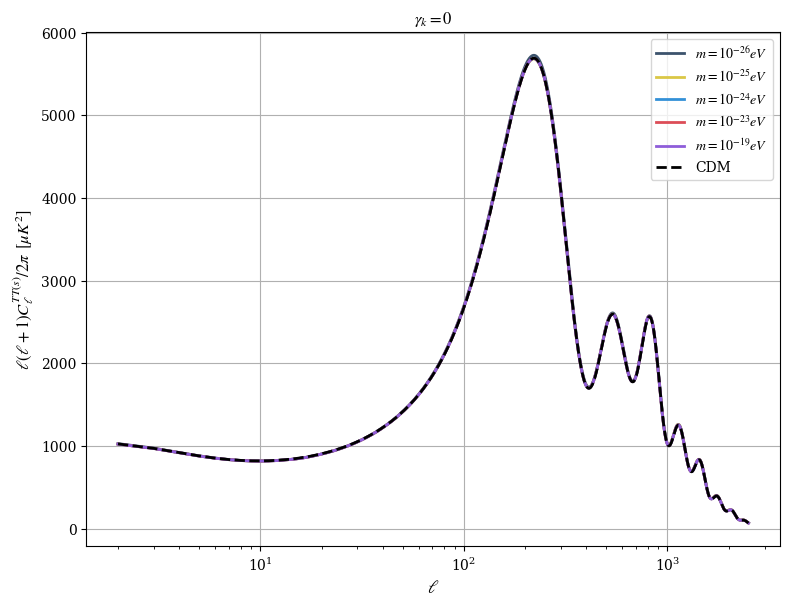

In [5]:
plt.figure(figsize=(8, 6))
for m in range(len(masses)):

    cls_lcdm = lcdm.raw_cl(2500)
    ll_lcdm = cls_lcdm['ell']
    factor_lcdm = 7.4311e12*ll_lcdm*(ll_lcdm+1.)/2./np.pi
    ell, TT, EE, TE = np.loadtxt("../../SFDM_data/Cls_AxionCAMB/test_scalCls%s.dat"%str(masses[m])[-3:], unpack=True)

    plt.figure(1)
    plt.plot(ell, TT, color=colors[m], label=r'$m=10^{%s}eV$'% str(masses[m])[-3:], lw=2)
    plt.ylabel(r"$\ell (\ell+1) C^{TT(s)}_\ell / 2 \pi \,\,\, [\mu K^2]$", size=12)
    plt.xlabel(r'$\ell$', size=13)
    plt.xscale('log')

    if masses[m] == masses[-1]:
        plt.plot(ll_lcdm[2:], factor_lcdm[2:]*cls_lcdm['tt'][2:], 'k--', label=r'CDM', lw=2)
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.title(r'$\gamma_k = 0$')
plt.show()

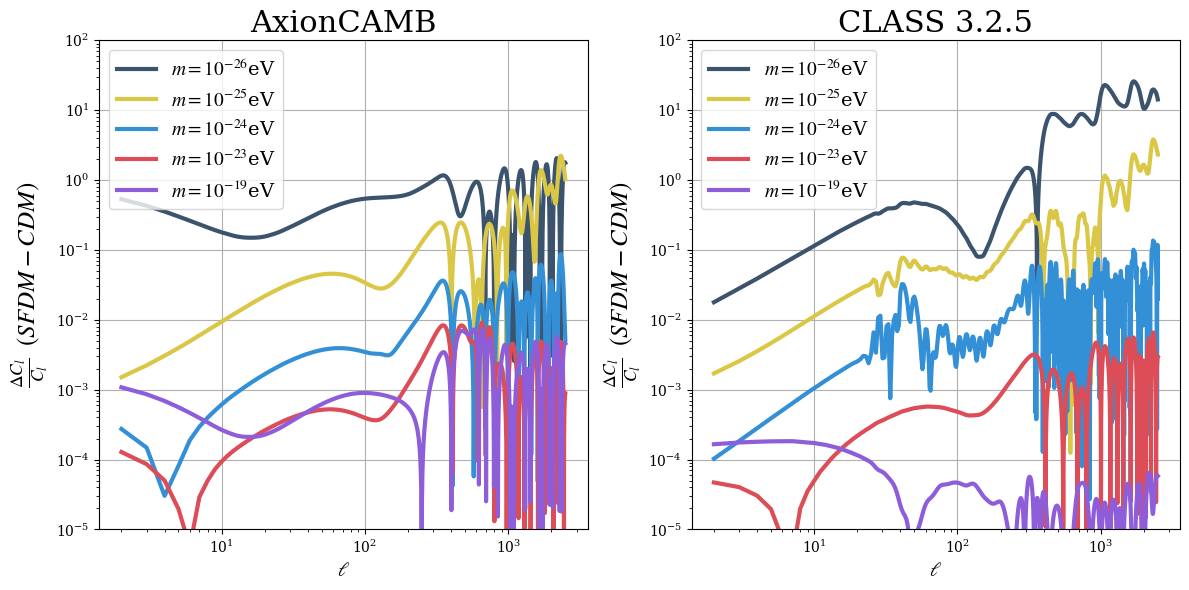

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()   # so we can index axes[m]
for m in range(len(masses)):

    #ax = axes[m]   # select subplot
    l_max_scalars = 2500
    cls0 = cosmo0[m].raw_cl(l_max_scalars)
    ll0 = cls0['ell']
    factor_lcdm = 7.4311e12*ll0*(ll0+1.)/2./np.pi
    cls_lcdm = lcdm.raw_cl(l_max_scalars)
    ellcdm, TTcdm, EEcdm, TEcdm = np.loadtxt("../../SFDM_data/Cls_AxionCAMB/test_scalCls-CDM.dat", unpack=True)
    ell, TT, EE, TE = np.loadtxt("../../SFDM_data/Cls_AxionCAMB/test_scalCls%s.dat"%str(masses[m])[-3:], unpack=True)
    
    err0 = [100 * np.abs(1 - TT[i]/TTcdm[i]) for i in range(len(cls0['tt'][2:]))]
    err1 = [100 * np.abs(1 - cls0['tt'][2:][i]/cls_lcdm['tt'][2:][i]) for i in range(len(cls0['tt'][2:]))]

    # Plot
    axes[0].plot(ll0[2:], err0, color=colors[m], label=r'$m=10^{%s}$eV'% str(masses[m])[-3:], lw=3)
    axes[1].plot(ll0[2:], err1, color=colors[m], label=r'$m=10^{%s}$eV'% str(masses[m])[-3:], lw=3)


    axes[0].set_ylabel(r'$\frac{\Delta C_l}{C_l}\,\,\;(SFDM - CDM)$', fontsize=18)
    axes[1].set_ylabel(r'$\frac{\Delta C_l}{C_l}\,\,\;(SFDM - CDM)$', fontsize=18)
    axes[0].set_ylim(1.e-5, 1.e2)
    axes[1].set_ylim(1.e-5, 1.e2)

for i in range(2):
    ax = axes[i]
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$', fontsize=14)
    ax.grid()
    ax.legend(fontsize=14)
axes[0].set_title(r'AxionCAMB', fontsize=22)
axes[1].set_title(r'CLASS 3.2.5', fontsize=22)
plt.tight_layout()
plt.show()

## Cl terms

In [7]:
M = Class()

M.set(common_settings)
M.set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 1.e-2'%1.e-22})
M.compute()
cl_tot = M.raw_cl(2500)
M.empty()           # reset input
#
M.set(common_settings)
M.set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 1.e-2'%1.e-22})
M.set({'temperature contributions':'tsw'}) 
M.compute()
cl_tsw = M.raw_cl(2500) 
M.empty()
#
M.set(common_settings)
M.set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 1.e-2'%1.e-22})
M.set({'temperature contributions':'eisw'})
M.compute()
cl_eisw = M.raw_cl(2500) 
M.empty()
#
M.set(common_settings)
M.set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 1.e-2'%1.e-22})
M.set({'temperature contributions':'lisw'})
M.compute()
cl_lisw = M.raw_cl(2500) 
M.empty()
#
M.set(common_settings)
M.set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 1.e-2'%1.e-22})
M.set({'temperature contributions':'dop'})
M.compute()
cl_dop = M.raw_cl(2500) 
M.empty()

In [8]:
# =========================
# LCDM model
# =========================
M_lcdm = Class()

# Total
M_lcdm.set(lcdm_settings)
M_lcdm.compute()
cl_tot_lcdm = M_lcdm.raw_cl(2500)
M_lcdm.empty()

# Sachs–Wolfe
M_lcdm.set(lcdm_settings)
M_lcdm.set({'temperature contributions': 'tsw'})
M_lcdm.compute()
cl_tsw_lcdm = M_lcdm.raw_cl(2500)
M_lcdm.empty()

# Early ISW
M_lcdm.set(lcdm_settings)
M_lcdm.set({'temperature contributions': 'eisw'})
M_lcdm.compute()
cl_eisw_lcdm = M_lcdm.raw_cl(2500)
M_lcdm.empty()

# Late ISW
M_lcdm.set(lcdm_settings)
M_lcdm.set({'temperature contributions': 'lisw'})
M_lcdm.compute()
cl_lisw_lcdm = M_lcdm.raw_cl(2500)
M_lcdm.empty()

# Doppler
M_lcdm.set(lcdm_settings)
M_lcdm.set({'temperature contributions': 'dop'})
M_lcdm.compute()
cl_dop_lcdm = M_lcdm.raw_cl(2500)
M_lcdm.empty()


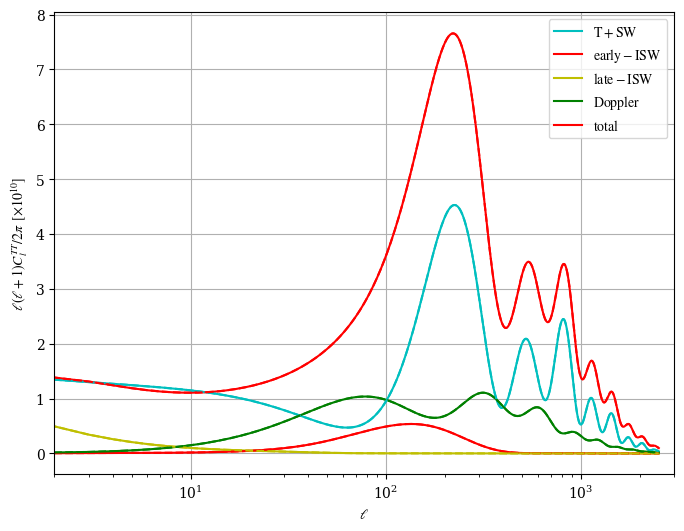

In [9]:
plt.figure(figsize=(8, 6))
plt.xlim([2,3000])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell (\ell+1) C_l^{TT} / 2 \pi \,\,\, [\times 10^{10}]$")
plt.grid()
#
ell = cl_tot['ell']
factor = 1.e10*ell*(ell+1.)/2./np.pi
plt.semilogx(ell,factor*cl_tsw['tt'],'c-',label=r'$\mathrm{T+SW}$')
plt.semilogx(ell,factor*cl_eisw['tt'],'r-',label=r'$\mathrm{early-ISW}$')
plt.semilogx(ell,factor*cl_lisw['tt'],'y-',label=r'$\mathrm{late-ISW}$')
plt.semilogx(ell,factor*cl_dop['tt'],'g-',label=r'$\mathrm{Doppler}$')
plt.semilogx(ell,factor*cl_tot['tt'],'r-',label=r'$\mathrm{total}$')
plt.semilogx(ell,factor*cl_tsw_lcdm['tt'],'c--')
plt.semilogx(ell,factor*cl_eisw_lcdm['tt'],'r--')
plt.semilogx(ell,factor*cl_lisw_lcdm['tt'],'y--')
plt.semilogx(ell,factor*cl_dop_lcdm['tt'],'g--')
plt.semilogx(ell,factor*cl_tot_lcdm['tt'],'r--')
#
plt.legend()

In [10]:
def percent_error(cl_vf, cl_lcdm, key='tt', ell_min=2):
    """
    Returns ell array and percentual error 100*(1-|Cl_vf/Cl_lcdm|)
    """
    ell = cl_lcdm['ell']
    mask = ell >= ell_min

    clv = cl_vf[key][mask]
    cll = cl_lcdm[key][mask]

    # avoid division by zero
    valid = cll != 0.0

    ell_out = ell[mask][valid]
    perr = 100.0 * np.abs((1.0 - clv[valid] / cll[valid]))

    return ell_out, perr

ell, err_tot  = percent_error(cl_tot,  cl_tot_lcdm)
_,   err_tsw  = percent_error(cl_tsw,  cl_tsw_lcdm)
_,   err_eisw = percent_error(cl_eisw, cl_eisw_lcdm)
_,   err_lisw = percent_error(cl_lisw, cl_lisw_lcdm)
_,   err_dop  = percent_error(cl_dop,  cl_dop_lcdm)


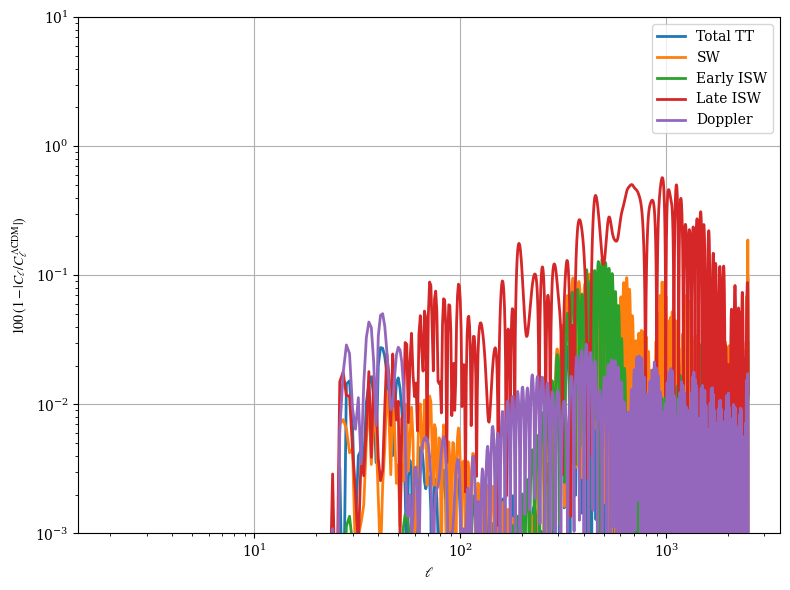

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.semilogx(ell, err_tot,  lw=2, label='Total TT')
plt.semilogx(ell, err_tsw,  lw=2, label='SW')
plt.semilogx(ell, err_eisw, lw=2, label='Early ISW')
plt.semilogx(ell, err_lisw, lw=2, label='Late ISW')
plt.semilogx(ell, err_dop,  lw=2, label='Doppler')
plt.yscale('log')
plt.axhline(0.0, color='k', lw=0.8)
plt.ylim(1e-3, 1.e1)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$100\,(1-|C_\ell/C_\ell^{\Lambda{\rm CDM}}|)$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
